# From global to local

One example runs **Fashion-MNIST, MNIST digits, and 20 Newsgroups** through the same pipeline: preprocess features, compute a warm-start DREAMS sequence, align the display coordinates, and export through **unmodified DataMapPlot**. Edit DATASETS below to run any subset.

The global endpoint is PCA (λ=1); intermediate layouts use DREAMS; the local endpoint uses t-SNE (λ=0). Labels determine sampling, colors, and hover content; they are never optimizer inputs. Zoom interpolation uses the precomputed layouts.

Use the **ZoomMap research** kernel and run all cells from the zoommap project. Installation is described in ../README.rst. The helper files live beside this notebook, and the reusable ZoomPositions package lives in src/zoommap/.

Sources: [DREAMS](https://github.com/berenslab/DREAMS), [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist), [MNIST](https://www.tensorflow.org/datasets/catalog/mnist), [20 Newsgroups](https://scikit-learn.org/stable/datasets/real_world.html#the-20-newsgroups-text-dataset).
Text features use [all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) sentence embeddings by default.

In [1]:
import os
from pathlib import Path
import sys
import json
from concurrent.futures import ThreadPoolExecutor
from contextlib import chdir
from importlib.metadata import distribution

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
assert (PROJECT / "pyproject.toml").exists(), "Start from zoommap/ or zoommap/notebooks/"
DATA = PROJECT / "data"
ARTIFACTS = PROJECT / "artifacts"
DATA.mkdir(exist_ok=True)
ARTIFACTS.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(DATA / "matplotlib"))
os.environ.setdefault("NUMBA_CACHE_DIR", str(DATA / "numba"))
sys.path.insert(0, str(PROJECT / "notebooks"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Opinionated checks bundled font names relative to its package directory.
# Import there to register bundled fonts without downloading other families.
with chdir(distribution("opinionated").locate_file("opinionated")):
    import opinionated
from IPython.display import display, HTML
import datamapplot
from zoommap import ZoomPositions, ZoomKeyframe
from dataset_helpers import load_example_dataset
from experiment_helpers import (
    DREAMS_COMMIT, fit_dreams_spectrum, align_for_display, quality_scores, plot_ui,
    use_bundled_jost,
)

print("DataMapPlot:", datamapplot.__file__)
print("DREAMS revision:", DREAMS_COMMIT)

/Users/Noich001/Desktop/moving_data_mapplot/zoommap/.venv/lib/python3.12/site-packages/opinionated/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/Users/Noich001/Desktop/moving_data_mapplot/zoommap/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DataMapPlot: /Users/Noich001/Desktop/moving_data_mapplot/zoommap/.venv/lib/python3.12/site-packages/datamapplot/__init__.py
DREAMS revision: eeea6a6985ded4fa926e4176a9dbd002eae14228


## Shared settings

By default each dataset uses **5,000 training observations**: 500 per digit/clothing class or 250 per newsgroup topic. Set SAMPLE_SIZE to None for the full available training data; full datasets retain their original unequal class counts. Downloads and raw optimizer results are cached.

Perplexity is fixed at 150 throughout each sequence. λ controls PCA regularization. Nonuniform zoom offsets allow denser keyframes where layouts change most. One zoom unit doubles camera magnification.

Two independent dataset sweeps may run concurrently; N_JOBS is the thread count per optimizer. Set PARALLEL_DATASETS to 1 to run them sequentially.

All Matplotlib plots use [Opinionated](https://github.com/MNoichl/opinionated) with the `opinionated_j` (Jost) preset. The interactive HTML maps use the same typeface for headings, legends, controls and hover content.

In [2]:
DATASETS = ["fashion_mnist", "mnist", "20_newsgroups"]
SAMPLE_SIZE = 5000
SEED = 42
N_ITER = 500
N_JOBS = 4
PARALLEL_DATASETS = 2
PERPLEXITY = 150
WARM_START = True
LAMBDAS = [1.0, 0.5, 0.25, 0.15, 0.05, 0.0]
ZOOM_OFFSETS = [0.0, 0.7, 1.05, 1.25, 1.55, 2.5]

# Text-specific preprocessing. Images use PCA-50 on pixels divided by 255.
TEXT_MODEL = "sentence-transformers/all-mpnet-base-v2"
TEXT_MODEL_REVISION = "e8c3b32edf5434bc2275fc9bab85f82640a19130"
EMBEDDING_BATCH_SIZE = 32
EMBEDDING_DEVICE = None       # automatic accelerator selection; or "cpu", "mps", "cuda"
TEXT_MAX_SEQ_LENGTH = 384     # wordpieces, including special tokens

# Use Opinionated's Jost stylesheet for all Matplotlib plots.
PLOT_STYLE = "opinionated_j"
plt.style.use(PLOT_STYLE)
plt.rcParams["axes.titlesize"] = 11
PLOT_BACKGROUND = "#eff0eb"
plt.rcParams["figure.facecolor"] = PLOT_BACKGROUND
plt.rcParams["axes.facecolor"] = PLOT_BACKGROUND
plt.rcParams["savefig.facecolor"] = PLOT_BACKGROUND
PLOT_FONT = plt.rcParams["font.sans-serif"][0]
assert PLOT_FONT == "Jost"
print(f"Plot style: {PLOT_STYLE}; font: {PLOT_FONT}")

EQUALIZE_SCALE = True
INTERPOLATION = "linear"       # "linear" or "pchip"
EASING = "linear"              # "linear", "smoothstep", "smootherstep"
assert DATASETS and len(DATASETS) == len(set(DATASETS))
assert len(LAMBDAS) == len(ZOOM_OFFSETS)
assert PARALLEL_DATASETS >= 1

Plot style: opinionated_j; font: Jost


## Prepare image and text features

**Fashion-MNIST and MNIST:** use the original 28×28 grayscale training images, divide pixels by 255, then compute seeded PCA-50. The first two components supply the shared global PCA reference.

**20 Newsgroups:** load the training split with headers, footers, and quoted text removed. Exclude empty cleaned documents, then select a balanced sample. Encode the cleaned text with **sentence-transformers/all-mpnet-base-v2**, pinned to the model commit above, and L2-normalize the resulting **768-dimensional** vectors. A full PCA rotation centers these vectors and supplies the global reference **without dropping dimensions or changing pairwise Euclidean distances**. DREAMS therefore uses the cosine geometry of the normalized MPNet embeddings.

MPNet uses at most **384 wordpieces per document**, including special tokens; longer documents are truncated. It embeds the document text, not the 1,200-character tooltip excerpt. Model weights and embeddings are cached locally; the vector cache includes text contents, row order, model revision, token settings and library versions. SentenceTransformers selects an available accelerator, falling back to CPU. Set EMBEDDING_DEVICE explicitly to override that choice.

The original training-row IDs stay attached to every observation. Preprocessing settings are exported separately for each dataset. Image tooltips show thumbnails; document tooltips show escaped excerpts from the cleaned text.

In [3]:
datasets = {}
for name in DATASETS:
    print(f"Preparing {name}…", flush=True)
    dataset = load_example_dataset(
        name, DATA, SAMPLE_SIZE, SEED,
        model_name=TEXT_MODEL,
        model_revision=TEXT_MODEL_REVISION, embedding_batch_size=EMBEDDING_BATCH_SIZE,
        embedding_device=EMBEDDING_DEVICE, max_seq_length=TEXT_MAX_SEQ_LENGTH,
    )
    datasets[name] = dataset
    settings = dict(dataset.preprocessing, requested_sample_size=SAMPLE_SIZE,
                    actual_sample_size=len(dataset.sample_ids))
    if "embedding_cache" in settings:
        settings["embedding_cache"] = str(Path(settings["embedding_cache"]).relative_to(PROJECT))
    (ARTIFACTS / f"{name}_preprocessing.json").write_text(json.dumps(settings, indent=2))
    print(f"{dataset.title}: {len(dataset.sample_ids):,} {dataset.noun}; "
          f"{dataset.features.shape[1]} feature dimensions", flush=True)
    display(pd.DataFrame({
        "class": dataset.class_names,
        "samples": np.bincount(dataset.labels, minlength=len(dataset.class_names)),
    }))
    display(pd.Series(settings, name="preprocessing"))

Preparing fashion_mnist…


Fashion-MNIST: 5,000 images; 50 feature dimensions


,class,samples
0,T-shirt/top,500
1,Trouser,500
2,Pullover,500
3,Dress,500
4,Coat,500
5,Sandal,500
6,Shirt,500
7,Sneaker,500
8,Bag,500
9,Ankle boot,500


subset                            train
pixel_scale               divide by 255
pca_components                       50
pca_explained_variance         0.864945
seed                                 42
requested_sample_size              5000
actual_sample_size                 5000
Name: preprocessing, dtype: object

Preparing mnist…


...

Preparing 20_newsgroups…


Sentence embeddings: reused embeddings-7d8e8a806322fa66.npz


20 Newsgroups · MPNet: 5,000 documents; 768 feature dimensions


,class,samples
0,alt.atheism,250
1,comp.graphics,250
2,comp.os.ms-windows.misc,250
3,comp.sys.ibm.pc.hardware,250
4,comp.sys.mac.hardware,250
5,comp.windows.x,250
6,misc.forsale,250
7,rec.autos,250
8,rec.motorcycles,250
9,rec.sport.baseball,250


source                                      scikit-learn fetch_20newsgroups
subset                                                                train
remove                                           [headers, footers, quotes]
original_documents                                                    11314
usable_documents                                                      11014
selected_documents                                                     5000
text_representation                                                   mpnet
document_filter                                       nonempty cleaned text
documents                                                              5000
embedding_dtype                                                     float32
long_document_policy      truncate each cleaned document to max_seq_leng...
max_seq_length                                                          384
model                               sentence-transformers/all-mpnet-base-v2
model_revisi

## Fit one global-to-local sequence per dataset

With WARM_START=True, the first optimized layout starts from scaled PCA. Each subsequent fit uses a copy of the preceding **raw optimized coordinates at their existing scale**, without repeating early exaggeration. The **PCA regularization reference remains fixed**. Set WARM_START=False to compare independent fits from a common PCA initialization.

λ=1 is the analytic PCA endpoint; λ=0 disables the regularizer. The same observations, features, perplexity, and seed are used throughout each sweep. Cache keys include the features, observation IDs, optimizer settings, initialization policy, and ordered λ sequence. Each cache file records its actual initial coordinates and PCA reference, so partial runs resume consistently.

The pinned DREAMS fork forwards an unused X optimizer parameter. The experiment helper removes it on the prepared embedding and uses the public optimization API; neither DREAMS nor DataMapPlot is patched. Warm starts can reduce rearrangement, but results depend on the sweep direction and intermediate λ values.

In [4]:
def fit_dataset(name):
    dataset = datasets[name]
    print(f"Starting {dataset.title}: perplexity={PERPLEXITY}, warm_start={WARM_START}", flush=True)
    # Fashion-MNIST retains the original cache location, reusing existing fits.
    cache_root = DATA / "dreams-cache"
    if name != "fashion_mnist":
        cache_root = cache_root / name
    fitted = fit_dreams_spectrum(
        dataset.features, dataset.sample_ids, LAMBDAS, cache_root,
        seed=SEED, n_iter=N_ITER, n_jobs=N_JOBS,
        perplexity=PERPLEXITY, warm_start=WARM_START,
    )
    print(f"Finished {dataset.title}: {fitted[2]}", flush=True)
    return fitted

results = {}
with ThreadPoolExecutor(max_workers=min(PARALLEL_DATASETS, len(DATASETS))) as pool:
    futures = {name: pool.submit(fit_dataset, name) for name in DATASETS}
    for name in DATASETS:
        raw_layouts, fit_report, cache_directory = futures[name].result()
        results[name] = {
            "raw_layouts": raw_layouts, "fit_report": fit_report,
            "cache_directory": cache_directory,
        }

Starting Fashion-MNIST: perplexity=150, warm_start=True
Starting MNIST: perplexity=150, warm_start=True


λ=1: loaded cached layout (analytic PCA)


λ=1: loaded cached layout (analytic PCA)


λ=0.5: loaded cached layout (scaled PCA)λ=0.5: loaded cached layout (scaled PCA)



λ=0.25: loaded cached layout (lambda=0.5)λ=0.25: loaded cached layout (lambda=0.5)



...

λ=0.25: loaded cached layout (lambda=0.5)


λ=0.15: loaded cached layout (lambda=0.25)


λ=0.05: loaded cached layout (lambda=0.15)


λ=0: loaded cached layout (lambda=0.05)


Finished 20 Newsgroups · MPNet: /Users/Noich001/Desktop/moving_data_mapplot/zoommap/data/dreams-cache/20_newsgroups/38f2ee5906ef4667


## Align display coordinates and inspect quality

Center each layout, optionally equalize its RMS radius, and align its rotation to PCA without reflections. These operations happen outside DataMapPlot, and raw optimizer coordinates are preserved.

The quality table measures kNN recall at k=10 and Spearman correlation of pairwise distances for 700 fixed sampled observations. Both compare against each dataset's processed feature space, with no labels involved in the scoring. RMS motion measures displacement between adjacent aligned keyframes. These scores describe the computed layouts; interpolation does not perform another DREAMS optimization.

In [5]:
reports = []
for name in DATASETS:
    dataset, result = datasets[name], results[name]
    raw_layouts = result["raw_layouts"]
    layouts = align_for_display(raw_layouts, equalize_scale=EQUALIZE_SCALE)
    result["layouts"] = layouts
    report = pd.concat([result["fit_report"], quality_scores(dataset.features, raw_layouts, SEED)], axis=1)
    report.insert(0, "dataset", name)
    report["zoom_offset"] = ZOOM_OFFSETS
    report["rms_motion_to_next"] = [
        float(np.sqrt(np.mean(np.sum((b - a) ** 2, axis=1))))
        for a, b in zip(layouts[:-1], layouts[1:])
    ] + [np.nan]
    result["report"] = report
    reports.append(report)
    report.to_csv(ARTIFACTS / f"{name}_report.csv", index=False)
    np.savez_compressed(
        ARTIFACTS / f"{name}_layouts.npz",
        raw_positions=np.stack(raw_layouts), display_positions=np.stack(layouts),
        sample_ids=dataset.sample_ids, class_ids=dataset.labels,
        class_names=np.asarray(dataset.class_names),
        lambdas=LAMBDAS, zoom_offsets=ZOOM_OFFSETS,
        perplexity=PERPLEXITY, warm_start=WARM_START,
    )
    display(HTML(f"<h3>{dataset.title}</h3>"))
    display(report.round(3))
combined_report = pd.concat(reports, ignore_index=True)
combined_report.to_csv(ARTIFACTS / "general_example_report.csv", index=False)

/Users/Noich001/Desktop/moving_data_mapplot/zoommap/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:134: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/Users/Noich001/Desktop/moving_data_mapplot/zoommap/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 264, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Noich001/Desktop/moving_data_mapplot/zoommap/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 420, in _count_physical_cores_darwin
    return int(cpu_info)
           ^^^^^^^^^^^^^


,dataset,lambda,method,cached,compute_seconds,initialization,early_exaggeration_iter,perplexity,knn_recall,distance_correlation,zoom_offset,rms_motion_to_next
0,fashion_mnist,1.00,PCA endpoint,True,0.001,analytic PCA,0,150,0.096,0.901,0.00,1.040
1,fashion_mnist,0.50,DREAMS,True,78.457,scaled PCA,250,150,0.352,0.864,0.70,0.952
2,fashion_mnist,0.25,DREAMS,True,53.362,lambda=0.5,0,150,0.401,0.807,1.05,0.447
3,fashion_mnist,0.15,DREAMS,True,52.422,lambda=0.25,0,150,0.412,0.779,1.25,0.776
4,fashion_mnist,0.05,DREAMS,True,51.752,lambda=0.15,0,150,0.421,0.723,1.55,0.391
5,fashion_mnist,0.00,t-SNE endpoint,True,51.587,lambda=0.05,0,150,0.422,0.700,2.50,NaN


,dataset,lambda,method,cached,compute_seconds,initialization,early_exaggeration_iter,perplexity,knn_recall,distance_correlation,zoom_offset,rms_motion_to_next
0,mnist,1.00,PCA endpoint,True,0.001,analytic PCA,0,150,0.046,0.561,0.00,0.997
1,mnist,0.50,DREAMS,True,276.481,scaled PCA,250,150,0.263,0.498,0.70,0.588
2,mnist,0.25,DREAMS,True,177.195,lambda=0.5,0,150,0.367,0.454,1.05,0.387
3,mnist,0.15,DREAMS,True,176.871,lambda=0.25,0,150,0.393,0.433,1.25,0.300
4,mnist,0.05,DREAMS,True,174.150,lambda=0.15,0,150,0.415,0.430,1.55,0.168
5,mnist,0.00,t-SNE endpoint,True,142.946,lambda=0.05,0,150,0.419,0.430,2.50,NaN


,dataset,lambda,method,cached,compute_seconds,initialization,early_exaggeration_iter,perplexity,knn_recall,distance_correlation,zoom_offset,rms_motion_to_next
0,20_newsgroups,1.00,PCA endpoint,True,0.000,analytic PCA,0,150,0.022,0.339,0.00,0.077
1,20_newsgroups,0.50,DREAMS,True,207.048,scaled PCA,250,150,0.218,0.368,0.70,0.051
2,20_newsgroups,0.25,DREAMS,True,96.828,lambda=0.5,0,150,0.342,0.374,1.05,0.022
3,20_newsgroups,0.15,DREAMS,True,56.183,lambda=0.25,0,150,0.369,0.379,1.25,0.039
4,20_newsgroups,0.05,DREAMS,True,55.627,lambda=0.15,0,150,0.387,0.387,1.55,0.021
5,20_newsgroups,0.00,t-SNE endpoint,True,57.482,lambda=0.05,0,150,0.388,0.391,2.50,NaN


## Compare the real keyframes

These panels show the actual computed layouts at a common display scale. Class/topic colors are fixed across the sequence.

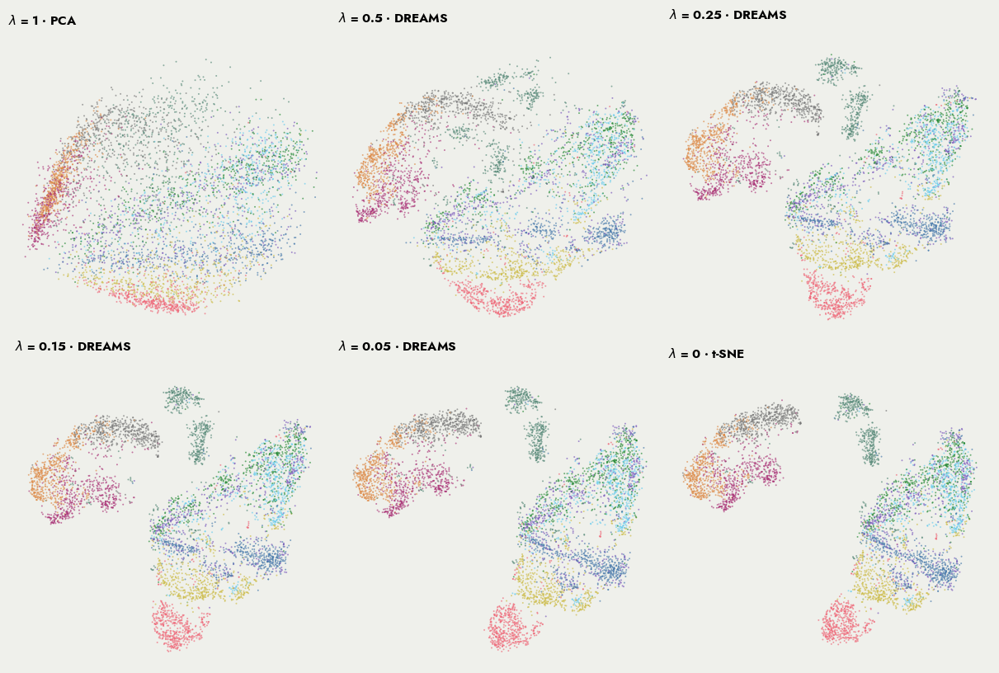

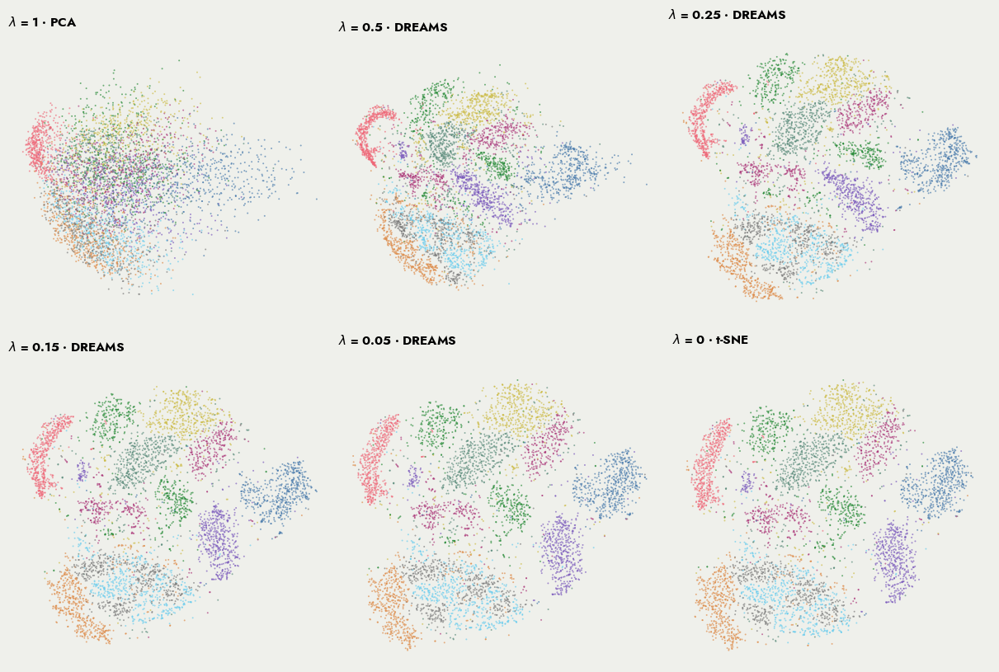

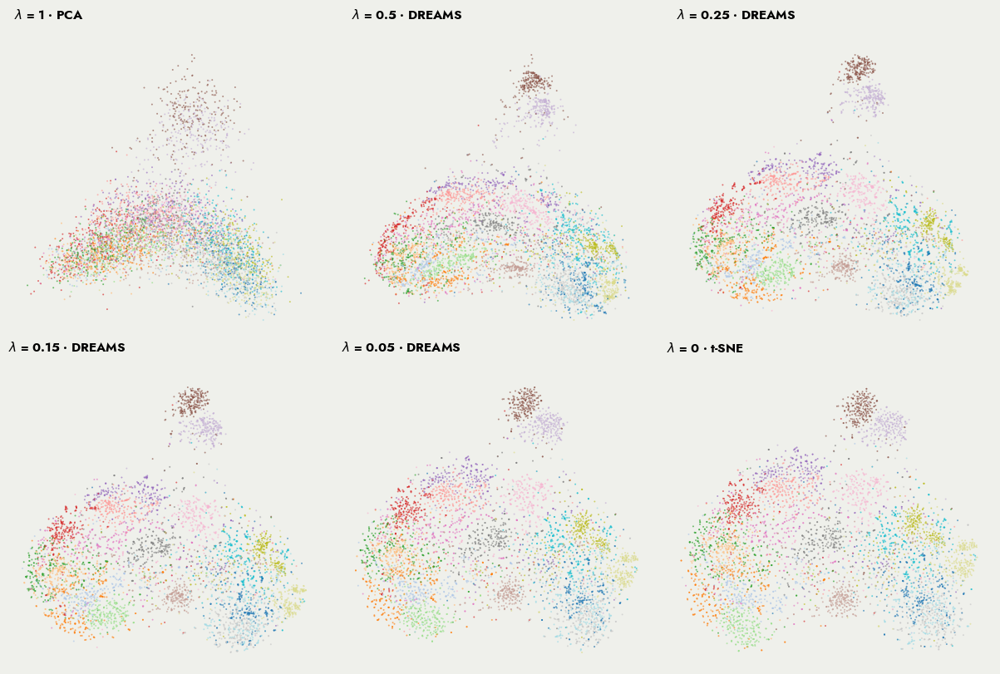

In [6]:
for name in DATASETS:
    dataset, result = datasets[name], results[name]
    class_colors = np.asarray(dataset.colors)[dataset.labels]
    result["class_colors"] = class_colors
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), layout="constrained")
    for ax, positions, strength in zip(axes.flat, result["layouts"], LAMBDAS):
        ax.scatter(positions[:, 0], positions[:, 1], c=class_colors, s=2, alpha=.65, linewidths=0)
        method = "PCA" if strength == 1 else "t-SNE" if strength == 0 else "DREAMS"
        ax.set_title(f"$\\lambda$ = {strength:g} · {method}")
        ax.set_aspect("equal")
        ax.set_axis_off()
    plt.show()

## Construct the ordered zoom keyframes

ZoomPositions accepts coordinates from any embedding method. Every frame must contain the same observations in the same row order. Zoom values can be unevenly spaced.

Linear interpolation takes straight segments. PCHIP uses a shape-preserving cubic on the actual zoom grid. Easing is independent: smoothstep or smootherstep stops movement at each knot. Per-interval options are also available through Transition objects.

In [7]:
for name in DATASETS:
    result = results[name]
    keyframes = [
        ZoomKeyframe(zoom, positions, f"λ={strength:g}")
        for zoom, positions, strength in zip(ZOOM_OFFSETS, result["layouts"], LAMBDAS)
    ]
    motion = ZoomPositions(keyframes, zoom_reference="initial",
                           interpolation=INTERPOLATION, easing=EASING)
    for frame in keyframes:
        np.testing.assert_allclose(motion.positions_at(frame.zoom), frame.positions, atol=1e-5)
    result.update(keyframes=keyframes, motion=motion)
    print(f"{datasets[name].title}: {len(keyframes)} keyframes, "
          f"{len(datasets[name].sample_ids):,} persistent point IDs")

Fashion-MNIST: 6 keyframes, 5,000 persistent point IDs
MNIST: 6 keyframes, 5,000 persistent point IDs
20 Newsgroups · MPNet: 6 keyframes, 5,000 persistent point IDs


## Export and display the interactive maps

This is the unchanged DataMapPlot function. ZoomPositions is passed through its existing custom_js parameter, alongside the optional example controls. Colors and image/document metadata are supplied once and remain attached to point IDs. Automatic point sizing lets dots grow naturally as you zoom in.

Each exported HTML file embeds its coordinates, hover metadata and Opinionated’s bundled Jost font. The optional font helper removes duplicate Google Fonts declarations from the generated HTML before saving and displaying it. It runs without Python, but uses the normal DataMapPlot CDN dependencies.

Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/artifacts/fashion_mnist_zoom.html (3.89 MB)


<InteractiveFigure width=100% height=800>
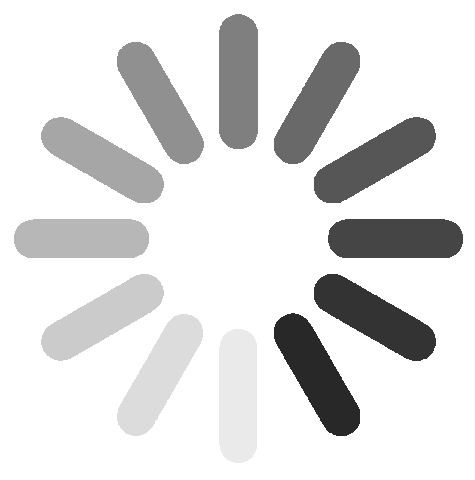

Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/artifacts/mnist_zoom.html (2.30 MB)


<InteractiveFigure width=100% height=800>
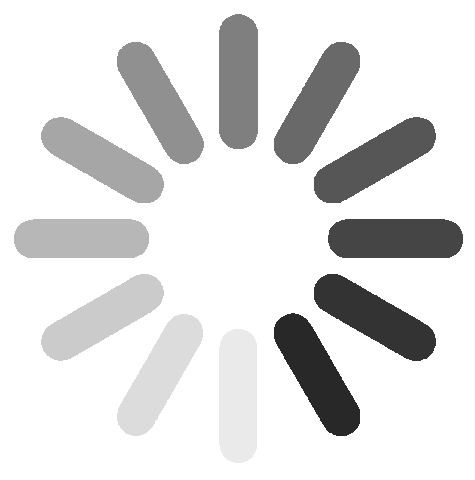

Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/artifacts/20_newsgroups_zoom.html (2.65 MB)


<InteractiveFigure width=100% height=800>
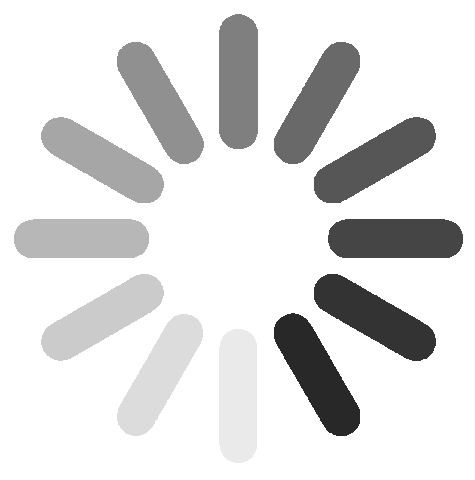

In [8]:
controls_js = (PROJECT / "notebooks" / "controls.js").read_text()
figures = {}
for name in DATASETS:
    dataset, result = datasets[name], results[name]
    custom_html, custom_css = plot_ui(
        dataset.title, len(dataset.sample_ids), dataset.noun,
        dataset.class_names, dataset.colors, PERPLEXITY,
    )
    figure = datamapplot.create_interactive_plot(
        result["layouts"][0], title=f"From global to local · {dataset.title}",
        marker_color_array=result["class_colors"],
        hover_text=[f"{dataset.class_names[int(label)]} · sample {index}"
                    for label, index in zip(dataset.labels, dataset.sample_ids)],
        extra_point_data=dataset.extra_data,
        hover_text_html_template=dataset.tooltip,
        point_radius_min_pixels=2.5, point_radius_max_pixels=10,
        point_size_scale=None, point_line_width=0,
        font_family=PLOT_FONT, tooltip_font_family=PLOT_FONT,
        background_color=PLOT_BACKGROUND, widgets=[], height=800,
        custom_html=custom_html, custom_css=custom_css,
        custom_js=result["motion"].to_javascript() + "\n" + controls_js,
    )
    figure = use_bundled_jost(figure)
    output = ARTIFACTS / f"{name}_zoom.html"
    figure.save(str(output))
    figures[name] = figure
    print(f"Saved {output} ({output.stat().st_size / 1e6:.2f} MB)")
    display(HTML(f"<h3>{dataset.title}</h3>"))
    display(figure)

## Compare interpolation without recomputing embeddings

The following paths follow one original observation from each dataset. Both interpolation methods respect the same endpoints and uneven zoom grid. Edit the settings above and rerun the plotting cells to export another option; the expensive fits stay cached.

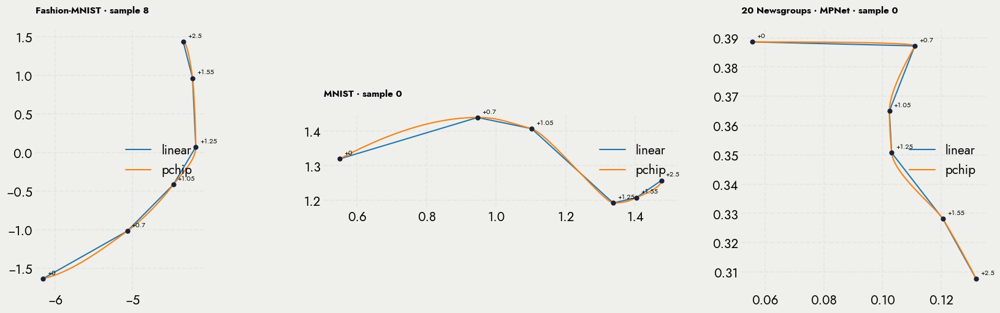

In [9]:
z = np.linspace(ZOOM_OFFSETS[0], ZOOM_OFFSETS[-1], 160)
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5), squeeze=False, layout="constrained")
for ax, name in zip(axes.flat, DATASETS):
    dataset, result = datasets[name], results[name]
    probe = 0
    for method in ["linear", "pchip"]:
        path = ZoomPositions(result["keyframes"], interpolation=method)
        trajectory = np.asarray([path.positions_at(zoom)[probe] for zoom in z])
        ax.plot(trajectory[:, 0], trajectory[:, 1], label=method, linewidth=1.5)
    anchors = np.asarray([frame.positions[probe] for frame in result["keyframes"]])
    ax.scatter(anchors[:, 0], anchors[:, 1], color="#182238", s=24, zorder=3)
    for xy, zoom in zip(anchors, ZOOM_OFFSETS):
        ax.annotate(f"+{zoom:g}", xy, xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.set_title(f"{dataset.title} · sample {dataset.sample_ids[probe]}")
    ax.set_aspect("equal")
    ax.legend()
plt.show()

The extension updates scatter positions and retains colors, filter attributes, point indices, and hover metadata. Labels, hulls, density tiles, minimaps, annotations, and lasso spatial indices require their own position updates and are absent here.

Zoom changes magnification and layout; pan keeps the current layout. Points can move away from the location under the cursor. Interpolated layouts are visual approximations between the real optimizer outputs.

Exports live in artifacts/: one interactive HTML map, coordinate archive, preprocessing description, quality report per dataset, plus a combined quality table. The data/ folder holds downloads, sentence embeddings, model weights and optimizer caches.